
> **여기서 처리하는 것** — 자료형 변환, 시간대 보정, 중복 정리, `price ≤ 0` 제외.
> 이 넷은 "데이터가 잘못 기록된 것"을 바로잡는 일이라 품질 점검에 속한다.
>
> **여기서 점검만 하는 것** — 결측 대체, 이상치 처리, 범주 묶기, 로그변환.
> 이 넷은 "모형에 맞게 데이터를 손보는 일"이라 ⑤ 모델링용 전처리에서 한다.

## #01. 준비작업

### 1. 라이브러리 참조

In [ ]:
import os, sys

# 프로젝트 폴더 — notebooks/ 안에서 실행하면 상위 폴더를 가리킨다
from pathlib import Path
BASE = str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd())
os.chdir(BASE)             # 폰트 경로가 상대경로라 여기서 실행해야 한다
sys.path.insert(0, BASE)

import gc
import os

from helpers import my_qtcheck, my_plot
from pandas import DataFrame, read_csv, concat, to_datetime
from pandas import Timedelta, cut, set_option
from datetime import timedelta as td

set_option("display.max_columns", 50)

### 2. 경로 지정

- 월별 CSV 두 개를 쓴다. 두 파일은 컬럼 구성이 같다.
- 컬럼이 같으므로 **조인이 아니라 세로 결합**이다.
- **두 사람의 폴더 구조가 다르다.** 아래에서 자기 블록만 주석을 풀고 나머지는 주석 처리한다.

| | 데이터 파일 위치 |
|---|---|
| 이슬기 | `BASE\data\2019-Oct.csv\2019-Oct.csv` — 폴더 안에 같은 이름의 파일이 한 겹 더 있다 |
| 배지환 | `BASE\2019-Oct.csv` — 파일이 바로 있다 |


In [2]:
# 원본 CSV — Kaggle에서 받아 data/ 아래에 둔다
FILES = {
    "2019-Oct": BASE + r"\data\2019-Oct.csv\2019-Oct.csv",
    "2019-Nov": BASE + r"\data\2019-Nov.csv\2019-Nov.csv",
}

OUT = BASE + r"\output"
FILES


{'2019-Oct': '.\\data\\2019-Oct.csv\\2019-Oct.csv',
 '2019-Nov': '.\\data\\2019-Nov.csv\\2019-Nov.csv'}

### 3. 경로가 맞는지 먼저 확인

- 파일 하나가 480MB대다. 경로가 틀린 채로 불러오면 한참 뒤에 오류가 난다.
- 읽기 전에 **파일이 그 자리에 있는지부터** 본다.


In [3]:
for name, path in FILES.items():
    print(name, ":", "파일 있음" if os.path.exists(path) else "★ 파일 없음 — 경로 확인", "|", path)


2019-Oct : 파일 있음 | .\data\2019-Oct.csv\2019-Oct.csv
2019-Nov : 파일 있음 | .\data\2019-Nov.csv\2019-Nov.csv


### 4. 나눠 읽기 함수 정의

- 파일 하나가 480MB대다. 통째로 올리면 메모리가 모자랄 수 있으므로 **100만 행씩 나눠 읽는다.**
- 나눠 읽는 것은 **한 번에 메모리에 올리는 양**을 줄이는 것이지 **행을 버리는 것이 아니다.**
- 읽은 조각을 하나도 빼지 않고 `concat`으로 이어 붙이므로 결과는 원본과 행 수가 같다.
- 그 사실은 `#02`에서 파일을 직접 세어 확인한다.

In [4]:
def load_month(path):
    parts = []

    for chunk in read_csv(path, chunksize=1_000_000):
        parts.append(chunk)

    return concat(parts, ignore_index=True)

### 5. 데이터 불러오기

> 이 단계에서는 **자료형을 바꾸지 않는다.**
> 프로세스상 ② 데이터 수집의 일은 "데이터 타입 **확인**"까지다.
> 타입 변환은 ③ 데이터 품질 점검에 속하므로 `#03`에서 한다.

In [5]:
origin = concat([load_month(p) for p in FILES.values()], ignore_index=True)
origin.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,cart,5773203,1487580005134238553,NaN,runail,2.62,463240011,26dd6e6e-4dac-4778-8d2c-92e149dab885
1,2019-10-01 00:00:03 UTC,cart,5773353,1487580005134238553,NaN,runail,2.62,463240011,26dd6e6e-4dac-4778-8d2c-92e149dab885
2,2019-10-01 00:00:07 UTC,cart,5881589,2151191071051219817,NaN,lovely,13.48,429681830,49e8d843-adf3-428b-a2c3-fe8bc6a307c9
3,2019-10-01 00:00:07 UTC,cart,5723490,1487580005134238553,NaN,runail,2.62,463240011,26dd6e6e-4dac-4778-8d2c-92e149dab885
4,2019-10-01 00:00:15 UTC,cart,5881449,1487580013522845895,NaN,lovely,0.56,429681830,49e8d843-adf3-428b-a2c3-fe8bc6a307c9


### 6. 행과 열의 수 확인

In [6]:
rows, cols = origin.shape
print(f"rows: {rows:,}, cols: {cols}")

rows: 8,738,120, cols: 9


## #02. 불러오기 검증

### 1. 원본 파일의 줄 수 세기

- 나눠 읽었기 때문에 행이 빠지지 않았는지 확인해야 한다.
- **불러온 것끼리 비교하면 검증이 되지 않는다.** 읽는 과정에서 흘린 행은 양쪽 모두에서 빠지기 때문이다.
- 그래서 파일을 한 줄씩 직접 세어서 대조한다. 헤더 1줄은 뺀다.

In [7]:
file_lines = {}

for name, path in FILES.items():
    with open(path, "r", encoding="utf-8", newline="") as f:
        file_lines[name] = sum(1 for _ in f) - 1

file_lines

{'2019-Oct': 4102283, '2019-Nov': 4635837}

### 2. 불러온 행 수 세기

- `event_time`은 아직 문자열이므로 **앞 7글자**(`2019-10`, `2019-11`)를 잘라 센다.

In [8]:
loaded = origin["event_time"].str.slice(0, 7).value_counts().sort_index()
loaded

event_time
2019-10    4102283
2019-11    4635837
Name: count, dtype: int64

### 3. 대조

In [9]:
check = DataFrame({
    "파일 줄 수": [file_lines["2019-Oct"], file_lines["2019-Nov"]],
    "불러온 행 수": [loaded["2019-10"], loaded["2019-11"]],
}, index=["2019-Oct", "2019-Nov"])

check["일치"] = check["파일 줄 수"] == check["불러온 행 수"]
check

,파일 줄 수,불러온 행 수,일치
2019-Oct,4102283,4102283,True
2019-Nov,4635837,4635837,True


> 두 파일 모두 일치하면 나눠 읽는 과정에서 **행 손실이 없다.**

## #03. 자료형 점검

### 1. 자료형 확인

In [10]:
origin.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 8738120 entries, 0 to 8738119
Data columns (total 9 columns):
 #   Column         Dtype  
---  ------         -----  
 0   event_time     str    
 1   event_type     str    
 2   product_id     int64  
 3   category_id    int64  
 4   category_code  str    
 5   brand          str    
 6   price          float64
 7   user_id        int64  
 8   user_session   str    
dtypes: float64(1), int64(3), str(5)
memory usage: 1.2 GB


### 2. 변수의 의미

| 컬럼 | 의미 |
|---|---|
| `event_time` | 이벤트 발생 시각 (UTC 표기) |
| `event_type` | 이벤트 종류 (view=조회, cart=담기, remove_from_cart=제거, purchase=구매) |
| `product_id` | 상품 식별자 |
| `category_id` | 카테고리 식별자 (익명 숫자) |
| `category_code` | 카테고리 이름 (예: appliances.environment.vacuum) |
| `brand` | 브랜드명 |
| `price` | 상품 가격 |
| `user_id` | 고객 식별자 |
| `user_session` | 세션 식별자 |

- 이 데이터의 한 줄은 "누가 · 언제 · 어떤 상품에 · 무엇을 했다"는 **행동 기록 하나**다.
- 한 사람이 여러 줄을 남기므로, 뒤에서 **1행 = 1고객**이 되도록 관측 단위를 바꿔야 한다(⑤).

In [11]:
# 컬럼 의미를 정리한 딕셔너리

column_means = {
    "event_time":     "이벤트 발생 시각",
    "event_type":     "이벤트 종류",
    "product_id":     "상품 식별자",
    "category_id":    "카테고리 식별자",
    "category_code":  "카테고리 이름",
    "brand":          "브랜드명",
    "price":          "상품 가격",
    "user_id":        "고객 식별자",
    "user_session":   "세션 식별자"
}


### 3. 형식 · 표기 점검 — `event_time`

- 타입을 바꾸기 **전에** 값이 어떤 형식으로 적혀 있는지 확인한다.
- 확인하지 않고 변환하면 조용히 값이 망가진다.

In [12]:
origin["event_time"].iloc[0]

'2019-10-01 00:00:00 UTC'

- 예시가 `2019-10-01 00:00:00 UTC` 형태다. 글자 수 23, 뒤 4글자가 ` UTC`다.
- **모든 행이 같은 형식인지** 두 가지로 센다. 뒤 4글자만 보면 앞부분이 다른 행을 놓친다.

In [13]:
et = origin["event_time"]

print(f"글자 수가 23이 아닌 행       : {(et.str.len() != 23).sum():,}건")
print(f"뒤 4글자가 ' UTC'가 아닌 행 : {(et.str.slice(19) != ' UTC').sum():,}건")

글자 수가 23이 아닌 행       : 0건
뒤 4글자가 ' UTC'가 아닌 행 : 0건


> 둘 다 0이면 전 행이 같은 표기 · 같은 시간대(UTC)다.
> 앞 19글자만 잘라 날짜형으로 바꿔도 **정보가 사라지지 않는다.**
> 기록 단위는 '초'까지이고 밀리초는 없다.
>
> ⚠️ 다만 **UTC 표기가 곧 이용자의 시각이라는 뜻은 아니다.**
> 담은 시각과 요일이 핵심 설명변수이므로, 시간대가 맞는지는 `#04`에서 따로 점검한다.

### 4. 단위 점검 — `price`

In [14]:
origin["price"].describe()

count    8.738120e+06
mean     8.315165e+00
std      1.895403e+01
min     -7.937000e+01
25%      2.050000e+00
50%      3.970000e+00
75%      6.780000e+00
max      3.277800e+02
Name: price, dtype: float64

> 통화 표기가 붙어 있지 않다. 중앙값 4 · 최댓값 328 규모로 보아 달러 단위로 추정된다.
> 단위가 명시되지 않았으므로 **절대 금액으로 해석하지 않고 상대 비교에만** 쓴다.

### 5. 표기 점검 — `category_code`

- 점(`.`)으로 계층을 구분한 표기다. 실제로 어떤 값이 들어 있는지는 결측 점검 뒤에 본다.

In [15]:
origin["category_code"].dropna().iloc[0]

'appliances.environment.vacuum'

### 6. 무엇을 무엇으로 바꿀 것인가

| 컬럼 | 지금 타입 | 바꿀 타입 | 왜 |
|---|---|---|---|
| `event_time` | 문자열 | **datetime** | 시간 계산(간격 · 기간)을 해야 한다. 문자열이면 뺄셈이 안 된다 |
| `event_type` · `category_code` · `brand` | 문자열 | **category** | 정해진 값 중 하나인 범주다. 문자열로 두면 메모리가 크고 범주형 기능도 못 쓴다 |
| `category_id` | int64 | **category** | 숫자로 적혀 있지만 크기 비교가 무의미한 **식별 코드**다. 숫자로 두면 연속형으로 오인된다 |
| `product_id` | int64 | **int32** | 최댓값이 590만이라 int32(약 21억) 안에 정확히 들어간다 |
| `user_id` | int64 | **그대로** | 값이 커서 int32로 줄이면 넘칠 위험이 있다 |
| `price` | float64 | **그대로** | float32로 줄이면 소수점 아래 값이 미세하게 달라진다 |
| `user_session` | 문자열 | **그대로** | 고유값이 약 181만 개다. category로 바꾸면 범주 목록 자체가 181만 개라 이득이 없다 |

> **`datetime64[ns]`로 강제하지 않는다.** pandas 3.0의 `to_datetime`은 `datetime64[us]`를 반환하는데,
> `.dt.hour` · `diff()` · `Timedelta` 연산은 모두 단위와 무관하게 정상 동작한다.
> 정수로 직접 환산하는 코드를 쓰지 않는 한 문제가 없고, `[ns]`는 표현 범위가 오히려 좁다.

### 7. `event_time` 변환

- ` UTC`는 전 행이 같으므로 **앞 19글자만** 잘라낸다.
- `format`을 직접 지정하면 파싱이 빠르고, 형식이 다른 행이 있으면 오류로 알려준다.

> ⚠️ **순서 주의** — 지금은 두 파일을 **문자열 상태로 먼저 합친 뒤** 한 번에 변환하므로 안전하다.
> 만약 파일별로 변환한 뒤 합치려 한다면, **날짜 컬럼과 문자열 컬럼을 섞어 `concat`하는 순간**
> 컬럼이 object가 되어 이후 변환이 **오류 없이 전부 `NaT`가 된다.**
> 어느 쪽을 택하든 아래 검증을 반드시 통과시킨다.

In [16]:
origin["event_time"] = to_datetime(origin["event_time"].str.slice(0, 19),
                                   format="%Y-%m-%d %H:%M:%S")

# 변환 검증 — NaT가 하나도 없어야 한다
print("dtype :", origin["event_time"].dtype)
print("NaT   :", origin["event_time"].isna().sum())
print(origin["event_time"].dt.to_period("M").value_counts().sort_index())

dtype : datetime64[us]
NaT   : 0
event_time
2019-10    4102283
2019-11    4635837
Freq: M, Name: count, dtype: int64


### 8. 나머지 자료형 변환

In [17]:
origin["product_id"] = origin["product_id"].astype("int32")

df1 = my_qtcheck.set_type(
    origin,
    as_category=["event_type", "category_code", "brand", "category_id"])

<class 'pandas.DataFrame'>
RangeIndex: 8738120 entries, 0 to 8738119
Data columns (total 9 columns):
 #   Column         Dtype         
---  ------         -----         
 0   event_time     datetime64[us]
 1   event_type     category      
 2   product_id     int32         
 3   category_id    category      
 4   category_code  category      
 5   brand          category      
 6   price          float64       
 7   user_id        int64         
 8   user_session   str           
dtypes: category(4), datetime64[us](1), float64(1), int32(1), int64(1), str(1)
memory usage: 651.0 MB


### 9. 변환 전 데이터 삭제

- `set_type`이 사본을 만들었으므로 원본은 지워 메모리를 돌려준다.
- 다시 돌릴 일이 없어졌을 때 실행한다.

In [18]:
del origin, et
gc.collect()

60

## #04. 시간대 점검

### 왜 이 장이 필요한가

`event_time`에 ` UTC`가 붙어 있다는 것은 **기록된 시각의 기준**이 UTC라는 뜻이지,
**이용자가 그 시각에 활동했다**는 뜻이 아니다.

이 프로젝트는 **담은 시각과 요일**을 핵심 설명변수로 쓴다.
시간대가 어긋난 채로 두면 "밤에 담으면 안 산다" 같은 결론이 **몇 시간씩 밀린 해석**이 되고,
자정 근처가 밀리면서 **요일까지 같이 틀어진다.**

가격의 통화 단위처럼, 시각의 시간대도 **점검 대상**이다.

### 1. 시각별 활동량 확인

- 사람의 하루 리듬은 정해져 있다. **새벽 3~5시에 가장 적고**, 낮과 저녁에 많다.
- 실제 분포가 그 모양인지 본다.

In [19]:
hourly = df1["event_time"].dt.hour.value_counts().sort_index()
hourly = DataFrame({"hour": hourly.index, "count": hourly.values})
hourly.T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
count,83596,80081,89260,121659,174239,265921,359101,419596,464526,485081,515224,525502,529573,491748,459411,438576,458701,499300,549771,572431,503821,338954,197103,114945


### 2. 가장 적은 시각과 가장 많은 시각

In [20]:
low  = hourly.loc[hourly["count"].idxmin()]
high = hourly.loc[hourly["count"].idxmax()]

print("최저 : %d시 (%s건)" % (low["hour"],  format(low["count"],  ",")))
print("최고 : %d시 (%s건)" % (high["hour"], format(high["count"], ",")))

print("활동이 가장 적은 4개 시각 :",
      sorted(hourly.nsmallest(4, "count")["hour"].to_list()))
print("활동이 가장 많은 4개 시각 :",
      sorted(hourly.nlargest(4, "count")["hour"].to_list()))

최저 : 1시 (80,081건)
최고 : 19시 (572,431건)
활동이 가장 적은 4개 시각 : [0, 1, 2, 23]
활동이 가장 많은 4개 시각 : [11, 12, 18, 19]


### 3. 분포를 눈으로 확인 (LAB-06 Line Plot)

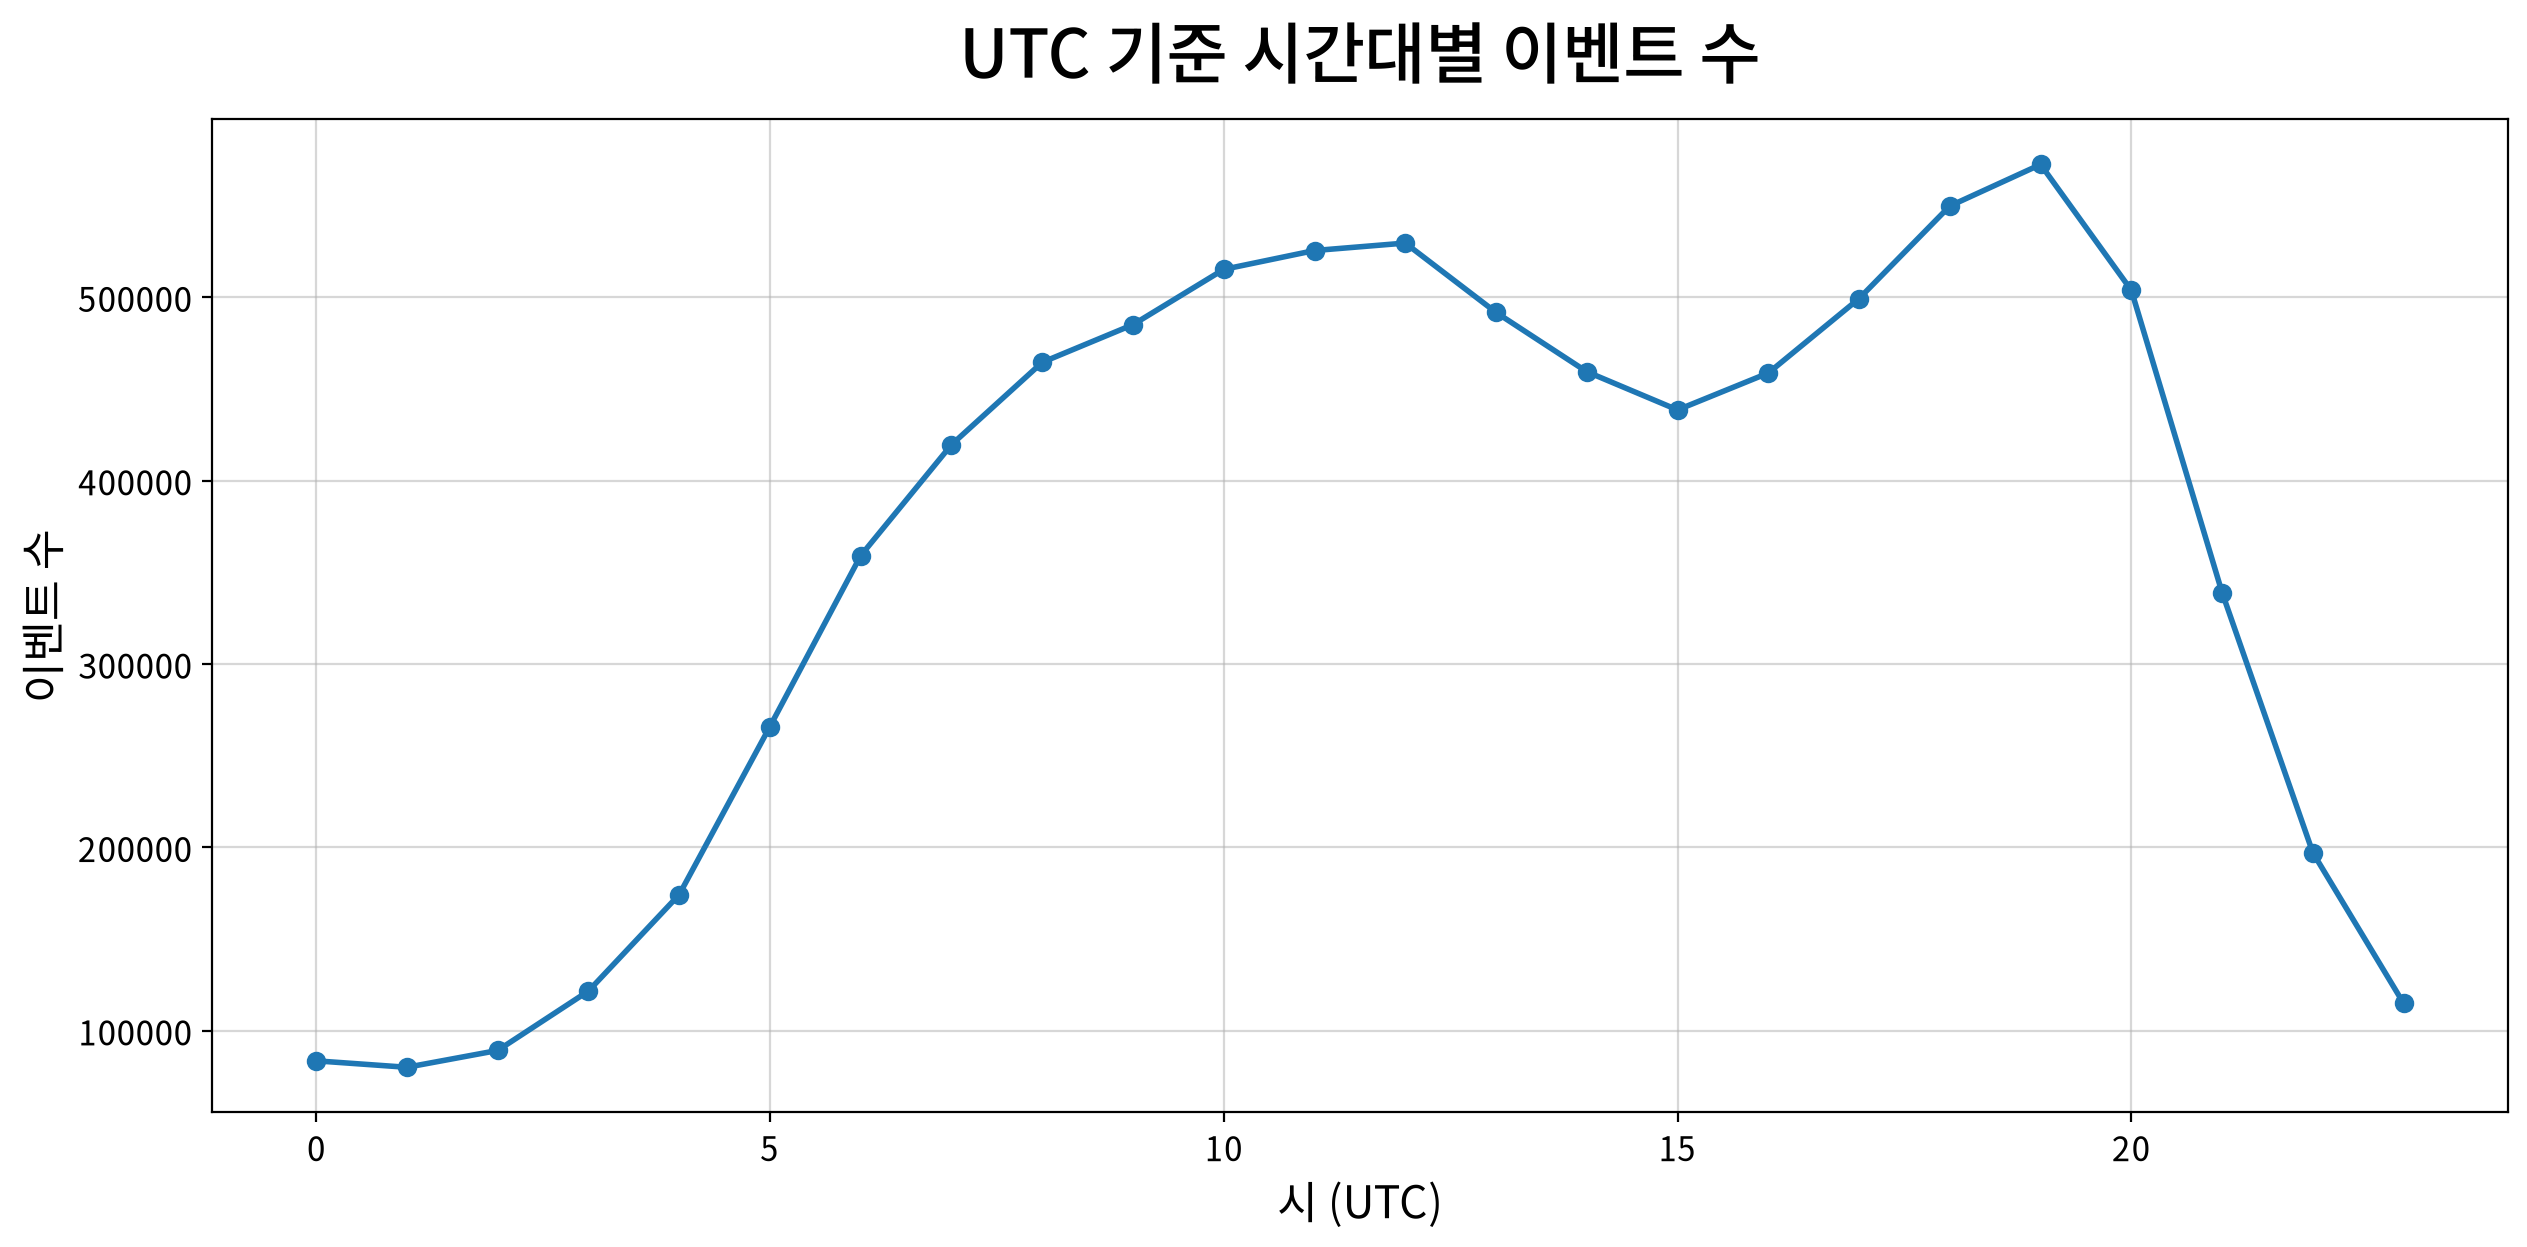

In [21]:
my_plot.lineplot(data=hourly, x="hour", y="count", marker="o",
                 title="UTC 기준 시간대별 이벤트 수",
                 xlabel="시 (UTC)", ylabel="이벤트 수")

### 4. 시간대를 옮겨 보면 어떻게 되는가

- 이 데이터를 공개한 REES46은 러시아 기반이고, 브랜드도 `runail` · `irisk` · `masura` 등 러시아 · CIS계다.
- 모스크바 시간은 **UTC+3**이다. 3시간을 더하면 분포가 어떻게 보이는지 확인한다.

In [22]:
SHIFT = 3      # 검토할 시차(시간)

shift_view = DataFrame({
    "UTC 기준"      : [int(low["hour"]), int(high["hour"])],
    f"UTC+{SHIFT} 기준": [(int(low["hour"]) + SHIFT) % 24,
                        (int(high["hour"]) + SHIFT) % 24],
}, index=["활동이 가장 적은 시각", "활동이 가장 많은 시각"])

shift_view

,UTC 기준,UTC+3 기준
활동이 가장 적은 시각,1,4
활동이 가장 많은 시각,19,22


### 5. 판정

| | UTC 그대로 읽으면 | UTC+3으로 읽으면 |
|---|---|---|
| 활동 최저 | 새벽 1시 — 아직 깨어 있는 사람이 많은 시간이다 | **새벽 4시** — 자는 시간이다 |
| 활동 최고 | 저녁 7시 | **밤 10시** — 퇴근 후 시간이다 |

**UTC 그대로 읽으면 설명이 어색하다.** 활동 바닥이 새벽 1시라는 것은 사람의 생활 리듬과 맞지 않는다.
**3시간을 더하면 그대로 일상 리듬이 된다.**

> **결론 — `UTC+3`(모스크바 시간)으로 보정한다.**
>
> 근거 세 가지다.
> ① 저점이 현지 새벽 4시로 정렬된다  ② 정점이 현지 밤 10시가 된다
> ③ 공개자 REES46과 브랜드 구성이 러시아 · CIS를 가리킨다
>
> ⚠️ 다만 제공처가 시간대를 명시한 문서는 없다.
> **시각 분포의 모양으로 추정한 것**이므로, 이 사실을 결과 보고서에도 함께 명시한다.

### 6. 시간대 보정

- 보정 전 상태는 보정 후와 비교하기 위해 보존한다.

In [23]:
# 보정 전 상태 기록
t_min_before = df1["event_time"].min()
t_max_before = df1["event_time"].max()
wd_before    = df1["event_time"].dt.dayofweek.value_counts().sort_index()

# 보정
df1["event_time"] = df1["event_time"] + Timedelta(hours=SHIFT)

print("보정 전 :", t_min_before, " ~ ", t_max_before)
print("보정 후 :", df1["event_time"].min(), " ~ ", df1["event_time"].max())

보정 전 : 2019-10-01 00:00:00  ~  2019-11-30 23:59:58
보정 후 : 2019-10-01 03:00:00  ~  2019-12-01 02:59:58


### 7. 검산

- 활동이 가장 적은 시각이 **새벽 3~5시**로 옮겨졌으면 제대로 보정한 것이다.
- 그 자리에 오지 않으면 시차 값을 다시 봐야 한다.

최저 : 4시 (80,081건)
최고 : 22시 (572,431건)


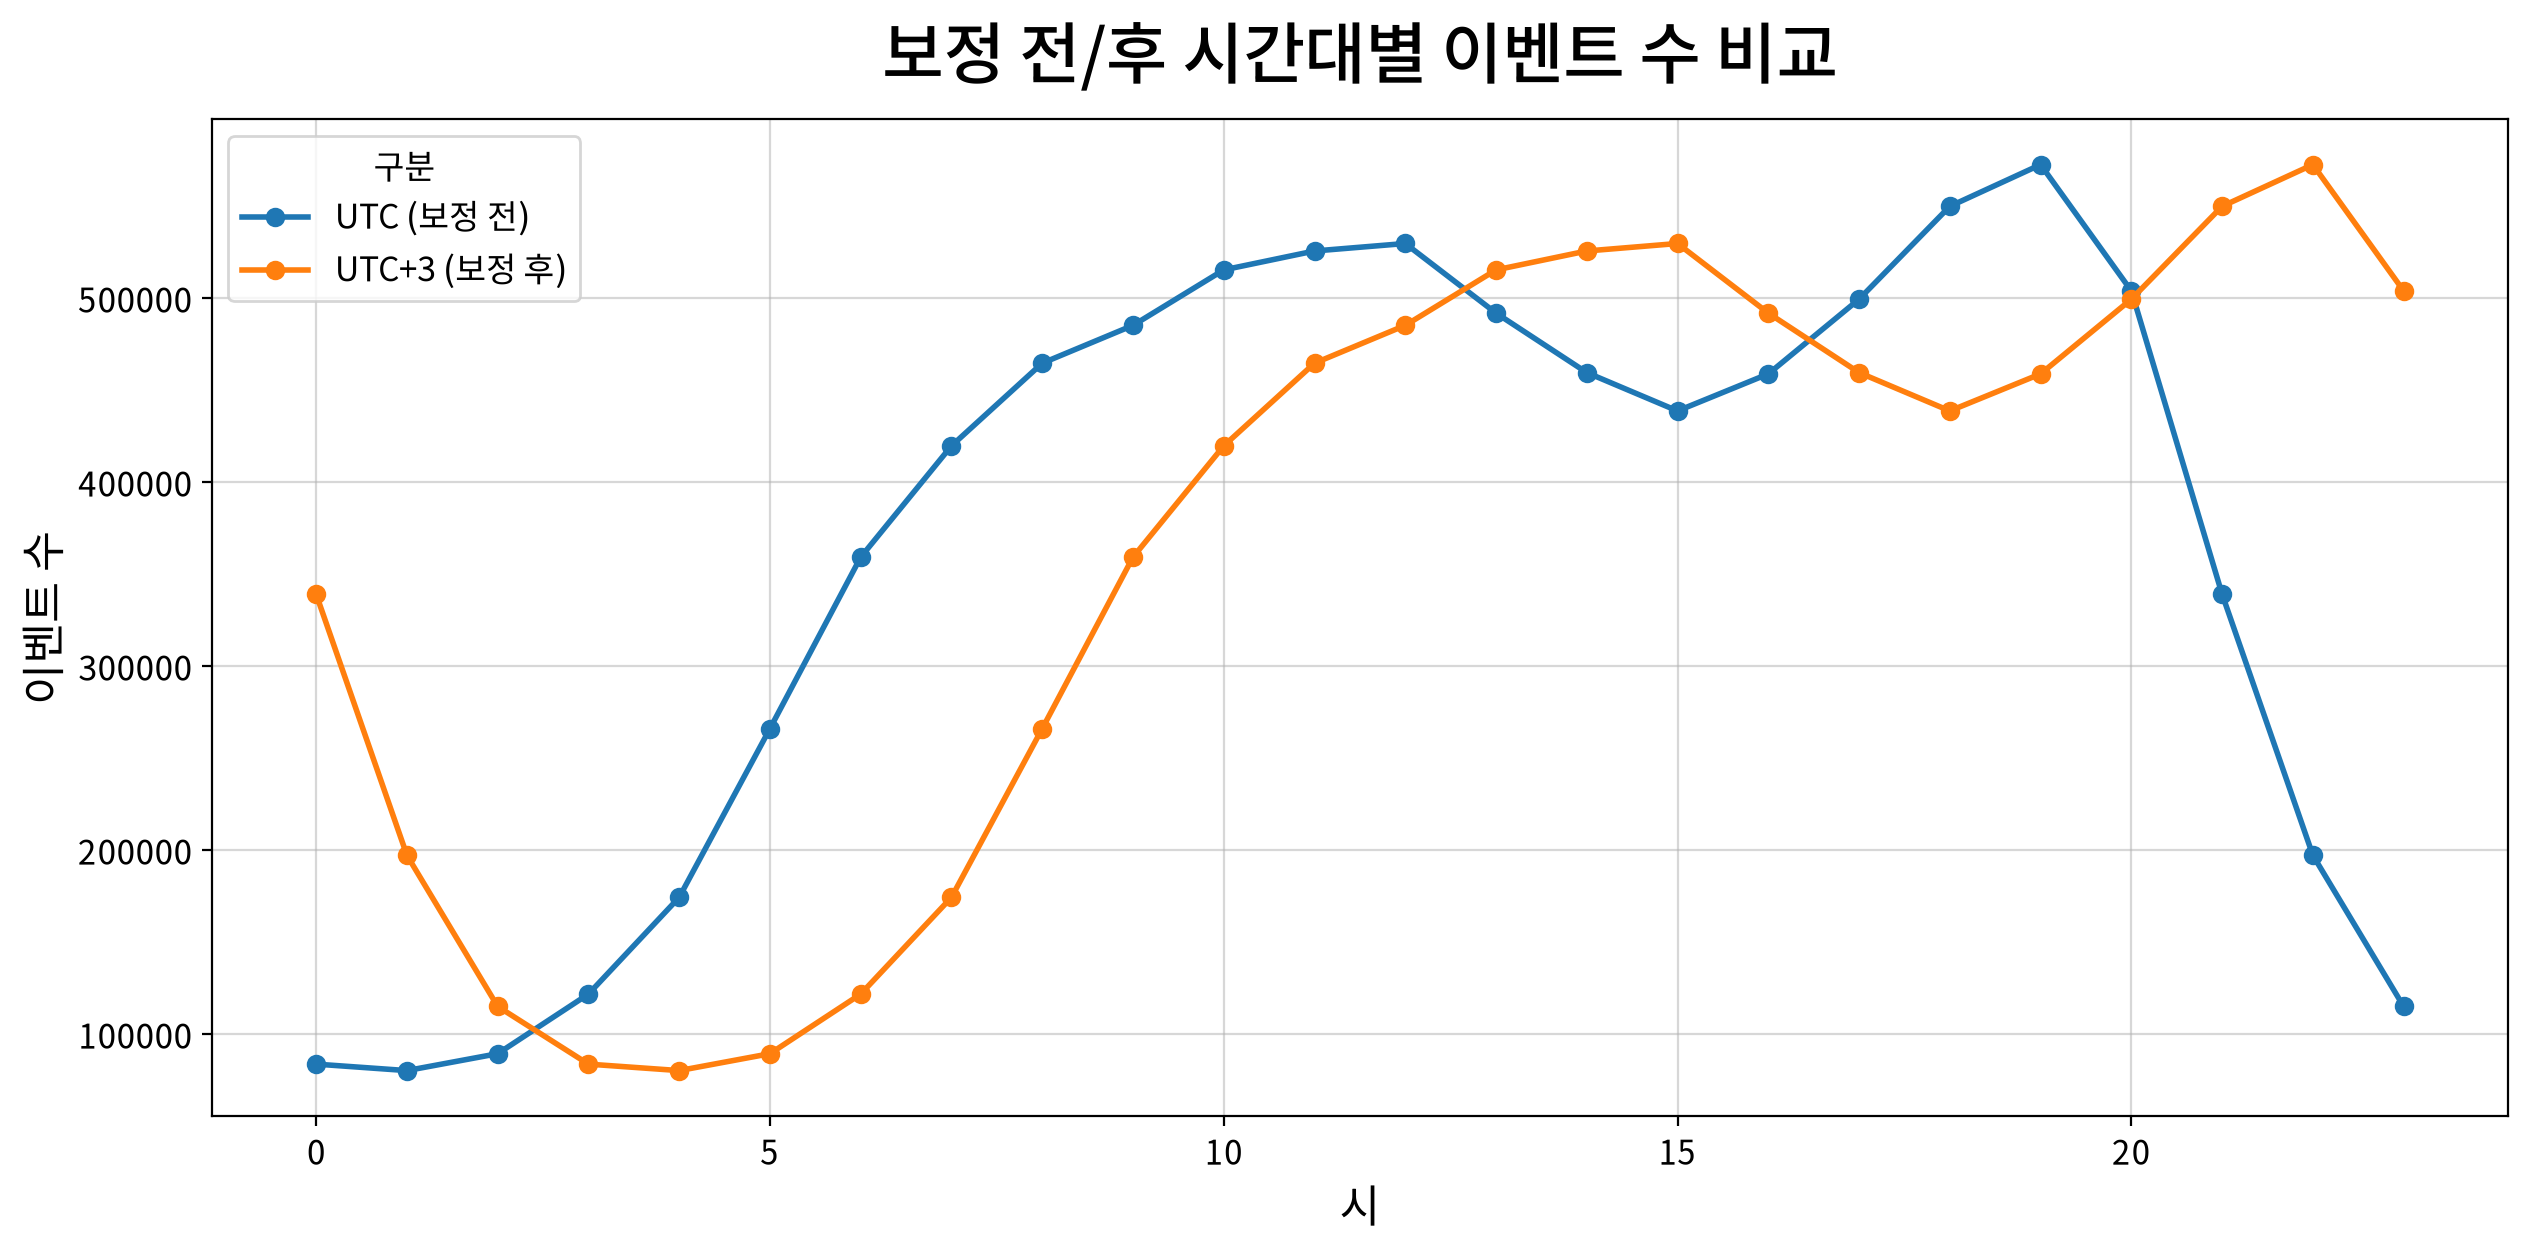

In [24]:
hourly2 = df1["event_time"].dt.hour.value_counts().sort_index()
hourly2 = DataFrame({"hour": hourly2.index, "count": hourly2.values})

low2  = hourly2.loc[hourly2["count"].idxmin()]
high2 = hourly2.loc[hourly2["count"].idxmax()]

print("최저 : %d시 (%s건)" % (low2["hour"],  format(low2["count"],  ",")))
print("최고 : %d시 (%s건)" % (high2["hour"], format(high2["count"], ",")))

hourly_cmp = concat([
    hourly.assign(구분="UTC (보정 전)"),
    hourly2.assign(구분=f"UTC+{SHIFT} (보정 후)")
], ignore_index=True)

my_plot.lineplot(data=hourly_cmp, x="hour", y="count", hue="구분", marker="o",
                 title="보정 전/후 시간대별 이벤트 수 비교",
                 xlabel="시", ylabel="이벤트 수")

### 8. 요일 분포 — 보정 전후 비교

- 자정 부근 이벤트가 다음 날로 넘어가므로 요일 건수가 바뀐다.
- 요일이 설명변수이므로 얼마나 바뀌는지 기록해 둔다.

In [ ]:
wd_after = df1["event_time"].dt.dayofweek.value_counts().sort_index()

DataFrame({
    "보정 전": wd_before.values,
    "보정 후": wd_after.values,
    "차이"   : wd_after.values - wd_before.values,
}, index=["월", "화", "수", "목", "금", "토", "일"])

,보정 전,보정 후,차이
월,1156982,1171104,14122
화,1248918,1237723,-11195
수,1304168,1293454,-10714
목,1412968,1414892,1924
금,1355547,1355194,-353
토,1132642,1125356,-7286
일,1126895,1140397,13502


## #05. 중복값 점검

### 1. 행 단위 완전 중복 확인

- 로그 데이터는 같은 이벤트가 여러 번 기록되는 일이 흔하다.
- 먼저 **9개 컬럼이 전부 같은 행**이 얼마나 되는지 센다.

In [ ]:
dup = df1.duplicated()
n_full = dup.sum()

print("완전 중복 : %s행 (%.2f%%)" % (format(n_full, ","), n_full / len(df1) * 100))

완전 중복 : 459,848행 (5.26%)


### 2. 처리 방침 — 목표변수와 설명변수가 중복에 다르게 반응한다

| | 중복이 남아 있으면 | |
|---|---|---|
| **목표변수** (`purchase_7d`) | 값이 바뀌지 않는다 | "샀는가"와 "언제 처음 샀는가"는 같은 기록이 세 번 있어도 같다 |
| **세는 설명변수** (`prior_view_cnt` · `cart_product_view_cnt`) | **부풀려진다** | 같은 조회가 세 번 기록돼 있으면 그대로 3으로 센다 |
| **종류를 세는 설명변수** (`prior_uniq_product`) | 영향 없다 | 같은 상품이 여러 번 있어도 **종류 수**는 그대로다 |
| **이진 설명변수** (`has_prior_view`) | 영향 없다 | 있고 없음만 보기 때문이다 |

중복이 **45만 행대**인데 그대로 두면 `cart_product_view_cnt`의 해석 자체가 흔들린다.
그래서 **목표변수와 설명변수를 모두 중복 정리 후의 표에서 산출**한다.

### 3. 집계 기준으로 정리

정리 기준은 `(user_id, product_id, event_type, event_time)` 네 컬럼이다.
같은 사람이 같은 상품에 같은 행동을 같은 초에 두 번 남긴 행을 하나로 본다.

> 이 기준은 9개 컬럼 전부를 보는 완전 중복보다 **넓다.**
> 네 컬럼은 같은데 `price` · `brand` · `user_session` 등이 다른 행이 있으면
> `keep='first'`가 **파일 순서로** 하나를 고르게 된다.
> 그런 행이 몇 건인지 함께 세어, 임의로 선택된 양이 얼마인지 남긴다.

In [ ]:
KEY = ["user_id", "product_id", "event_type", "event_time"]

before = len(df1)
df2 = df1.drop_duplicates(subset=KEY, keep="first")
after = len(df2)

n_key  = before - after      # 4개 컬럼 기준으로 지워진 행 수
n_pick = n_key - n_full      # 그중 나머지 컬럼의 값이 서로 달랐던 행 수

print(f"정리 전 : {before:,}행")
print(f"정리 후 : {after:,}행")
print(f"제거    : {n_key:,}행 ({n_key / before * 100:.2f}%)")
print("-" * 46)
print(f"  9개 컬럼이 전부 같아서 지워진 행   : {n_full:,}")
print(f"  4개 컬럼만 같고 나머지가 달랐던 행 : {n_pick:,}")

정리 전 : 8,738,120행
정리 후 : 8,276,671행
제거    : 461,449행 (5.28%)
----------------------------------------------
  9개 컬럼이 전부 같아서 지워진 행   : 459,848
  4개 컬럼만 같고 나머지가 달랐던 행 : 1,601


### 4. 네 컬럼만 같았던 행은 무엇이 달랐나

- `n_pick`이 0이면 지워진 행은 전부 완전한 판박이다. 무엇을 남기든 결과가 같다.
- 0이 아니면 어느 컬럼이 달랐는지 직접 본다. 분석에 쓰는 값이 달랐다면 그 사실을 기록해야 한다.
- 직접 확인 결과, 'user_session'만 다른 것을 확인할 수 있고, 분석에 직접 쓰이는 값이 아니므로 우선 기록 후 넘어간다.

In [ ]:
if n_pick > 0:
    mask = df1.duplicated(subset=KEY, keep=False) & ~df1.duplicated(keep=False)
    display(df1[mask].sort_values(KEY).head(20))
else:
    print("4개 컬럼 기준 정리 = 완전 중복 정리. 임의로 선택된 행 없음.")

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
7849918,2019-11-25 23:25:58,view,5774881,1487580005671109489,NaN,masura,1.73,128217878,1d091879-b390-4f19-a2b3-0f8ddd531f31
7849920,2019-11-25 23:25:58,view,5774881,1487580005671109489,NaN,masura,1.73,128217878,af2b0bb4-5516-4f58-bea1-9738d4ffdb78
4437535,2019-11-03 22:21:43,view,5898243,1487580007634043851,NaN,de.lux,0.79,172974485,2b6718f9-0e3f-491b-bdd8-164a81d03d11
4437537,2019-11-03 22:21:43,view,5898243,1487580007634043851,NaN,de.lux,0.79,172974485,ceebfee4-5900-4327-b48d-8bfe45798caf
4320891,2019-11-02 23:20:01,view,5888957,1487580011677352062,NaN,laboratorium,4.76,197904114,997972c5-bde2-459a-9d84-bde4dc58d3b7
4320895,2019-11-02 23:20:01,view,5888957,1487580011677352062,NaN,laboratorium,4.76,197904114,412ec6c4-9ec4-494e-8de5-7231dfc1c465
5191479,2019-11-08 18:50:27,view,5902747,1487580009445982239,NaN,NaN,13.97,197904114,5ec1b2d9-8ae5-4c31-a616-338dfc0206ba
5191481,2019-11-08 18:50:27,view,5902747,1487580009445982239,NaN,NaN,13.97,197904114,e160a5e8-6f09-4adb-818a-33e852b5a4dc
6336231,2019-11-17 19:10:23,view,5904006,1937169073007756269,NaN,lovely,5.54,197904114,689f2cf0-ff59-45ab-8722-d82c8d134716
6336233,2019-11-17 19:10:23,view,5904006,1937169073007756269,NaN,lovely,5.54,197904114,7b7602ae-57c4-4963-a494-3d1e0f3e06ba


### 5. 정리 전 데이터 삭제

- 위 확인이 끝난 뒤에 실행한다. `df1`이 있어야 `#05-4`를 다시 볼 수 있다.

In [ ]:
del df1, dup
gc.collect()

6431

## #06. 결측치 점검

### 1. 결측치 확인

> 이 표는 **중복 정리 후** 기준이다. 계획서에 적은 수치는 정리 전 기준이므로 소수점 아래가 다르다.
> 어느 시점 기준인지 항상 함께 적는다.

In [ ]:
miss = my_qtcheck.check_missing_values(df2)
miss.sort_values("Missing Ratio (%)", ascending=False)

,Missing Count,Missing Ratio (%)
category_code,8137762,98.321680
brand,3450632,41.691062
user_session,1329,0.016057
event_time,0,0.000000
event_type,0,0.000000
category_id,0,0.000000
product_id,0,0.000000
price,0,0.000000
user_id,0,0.000000


### 2. 결측을 어떻게 볼 것인가

| 컬럼 | 결측 | 판단 | 이유 |
|---|---|---|---|
| `category_code` | 약 98% | **컬럼째 사용하지 않는다** | 채울 근거가 없다. 남은 값도 화장품과 무관하다(아래 확인) |
| `brand` | 약 42% | **삭제하지 않고 '미상'을 하나의 범주로 둔다** | 40%대면 우연히 빠진 것으로 보기 어렵다. 결측 자체가 정보일 수 있다 |
| `user_session` | 0.02% | **아직 정하지 않는다** | 조회 변수를 세션 기준으로 만들지 시간 창 기준으로 만들지에 따라 달라진다. 세션을 쓰지 않기로 하면 제외할 이유가 없다 |

> 실제 처리는 ⑤ 모델링용 전처리에서 한다. 여기서는 **방침만** 정한다.

### 3. `category_code`에 실제로 들어 있는 값

- 결측이 98%여도 남은 2%가 쓸 만하면 살릴 수 있다. 직접 확인한다.

In [ ]:
cc = df2["category_code"].value_counts().rename("건수").to_frame()
cc["전체 대비 %"] = (cc["건수"] / len(df2) * 100).round(3)
cc

,건수,전체 대비 %
category_code,,
appliances.environment.vacuum,58389,0.705
stationery.cartrige,25389,0.307
apparel.glove,17270,0.209
furniture.living_room.cabinet,13263,0.160
accessories.bag,11602,0.140
furniture.bathroom.bath,9537,0.115
appliances.personal.hair_cutter,1628,0.020
accessories.cosmetic_bag,1200,0.014
appliances.environment.air_conditioner,326,0.004


> 진공청소기 · 프린터 카트리지 · 장갑 · 욕조 … **화장품 스토어와 맞지 않는 값뿐이다.**
> 고유값도 11종뿐이라 카테고리 축으로 쓸 수 없다.
> → 카테고리는 익명 숫자인 `category_id`로 대체한다.

## #07. 값의 분포 점검

### 1. 이벤트 유형 분포

- 이 프로젝트는 `cart`(담기)와 `purchase`(구매)가 **둘 다 있어야** 성립한다.

In [ ]:
ev = df2["event_type"].value_counts().rename("건수").to_frame()
ev["비율 %"] = (ev["건수"] / len(df2) * 100).round(2)
ev

,건수,비율 %
event_type,,
view,3936444,47.56
cart,2493848,30.13
remove_from_cart,1278829,15.45
purchase,567550,6.86


> 네 가지 이벤트가 모두 존재하면 주제가 성립한다.
> 다만 담기와 구매는 서로 다른 고객 · 다른 상품의 이벤트 수이므로 **나눠서 전환율로 읽으면 안 된다.**

### 2. 명목형 변수의 고유값 수

In [ ]:
df2.nunique().rename("고유값 수").to_frame()

,고유값 수
event_time,3593174
event_type,4
product_id,45960
category_id,500
category_code,11
brand,244
price,2600
user_id,713100
user_session,1812692


> `brand` 244종 · `category_id` 500종이다. 그대로 더미변수로 만들면 열이 폭증한다.
>
> **각 범주 최소 1,000건, 그 미만은 '기타'로 묶는다**(⑤에서 처리).
> 범주별 표본이 적으면 계수가 불안정해지므로, "분포를 보고 정한다"가 아니라
> **지금 기준값을 정해 둔다.** 나중에 결과에 유리한 쪽으로 기준을 고르는 일을 막기 위해서다.
>
> ⚠️ 다만 **1,000건을 어느 표에서 세는지**를 함께 정해야 한다.
> 이 로그(800만 행) 기준과 고객 단위 테이블(약 19만 행) 기준은 40배 차이라 결과가 전혀 달라진다.
> → ⑤에서 **고객 단위 테이블 기준**으로 세고, 남는 범주 수를 확인한 뒤 확정한다.

### 3. 가격의 기술통계량

In [ ]:
num_desc = my_qtcheck.numerical_summary(df2, columns=["price"])
num_desc.T

,price
count,8276671.0
mean,8.504001
std,19.31802
min,-79.37
25%,2.05
50%,3.97
75%,6.98
max,327.78
rel_diff,1.142066
rdiff_flag,large_diff


### 4. 음수 · 0원 확인

- 가격은 **음수가 될 수 없다.** 최솟값이 음수라면 오류다.

In [ ]:
zero1 = df2.loc[df2["price"] < 0]
# zero1["product_id"].value_counts()
zero1

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
112860,2019-10-01 22:10:56,purchase,5716857,1487580014042939619,NaN,NaN,-23.81,552507528,dcdd60c6-1a70-442d-bfb2-0252879054ad
198302,2019-10-02 11:30:03,purchase,5716855,1487580014042939619,NaN,NaN,-7.94,550375225,5ddec778-9464-4514-914d-be7b751b8e2c
436918,2019-10-03 20:37:04,purchase,5716859,1487580014042939619,NaN,NaN,-47.62,555414763,479149eb-1807-4178-8f6b-87c642350735
443204,2019-10-03 21:25:39,purchase,5670257,1487580014042939619,NaN,NaN,-15.87,556383221,4333d203-bc4d-4d0d-a6e1-0ea3a97a28c1
1295556,2019-10-09 17:49:14,purchase,5716855,1487580014042939619,NaN,NaN,-7.94,514562574,fed2aeb4-0c75-44f7-9ca8-1a8be8214779
1426186,2019-10-10 17:33:29,purchase,5716855,1487580014042939619,NaN,NaN,-7.94,558797258,a406cf28-f04b-4361-8e6a-c62d36045e07
1519246,2019-10-11 13:27:19,purchase,5716859,1487580014042939619,NaN,NaN,-47.62,543647038,85e11d74-6583-4eab-b50c-ff86dbb25d97
1783312,2019-10-13 19:46:01,purchase,5716857,1487580014042939619,NaN,NaN,-23.81,559820267,f178c995-f004-4040-b26d-b1cca0f9657d
1924072,2019-10-14 20:33:24,purchase,5716861,1487580014042939619,NaN,NaN,-79.37,541122983,b60f777d-afca-4299-8548-273b810d6130
2143762,2019-10-16 14:41:06,purchase,5716857,1487580014042939619,NaN,NaN,-23.81,461943726,beefa8fb-a3d1-48ca-97e9-9c95b05ee997


In [ ]:
neg  = (df2["price"] <  0).sum()
zero = (df2["price"] == 0).sum()
na   =  df2["price"].isna().sum()

print(f"가격 결측 : {na:,}건")
print(f"가격 < 0  : {neg:,}건")
print(f"가격 = 0  : {zero:,}건")
print(f"합계      : {neg + zero:,}건  ({(neg + zero) / len(df2) * 100:.3f}%)")

가격 결측 : 0건
가격 < 0  : 36건
가격 = 0  : 17,476건
합계      : 17,512건  (0.212%)


### 5. 무응답 코딩 점검

- 무응답을 9, 99, 999로 코딩해둔 데이터가 흔하다. 숫자로 읽히니 오류처럼 보이지 않는다.

In [ ]:
for v in [9, 99, 999]:
    print(f"price == {v:>3} : {(df2['price'] == v).sum():,}건")

price ==   9 : 762건
price ==  99 : 0건
price == 999 : 0건


> `9`가 있더라도 이 스토어 가격대(중앙값 4)에서는 **정상 범위**다. 99와 999가 0건이면
> 9 · 99 · 999식 무응답 코딩은 **없는 것으로 본다.**
> 대신 **음수 가격**이라는 다른 형태의 오류를 찾았다.

### 6. `price ≤ 0` 제외

- 음수 가격은 "값이 큰 관측치"가 아니라 **기록 오류**다. 이상치 처리가 아니라 무효값 제거다.
- `price` 왜도가 커서 ⑤에서 로그변환을 검토하는데, `log1p`는 −1보다 큰 값에서만 정의된다.
  **음수 제외가 반드시 먼저**다. 순서를 바꾸면 결측이 생긴다.
- 위에서 확인했듯 `price` 결측은 0건이므로, `> 0` 조건으로 걸러도 결측이 함께 빠지는 일은 없다.

In [ ]:
before = len(df2)
df3 = df2[df2["price"] > 0]

print(f"제외 : {before - len(df3):,}행  →  {len(df3):,}행")

제외 : 17,512행  →  8,259,159행


In [ ]:
del df2
gc.collect()

0

## #08. 파생 기준 확정

여기서 **값을 만들지는 않는다.** ⑤에서 쓸 기준만 확정해 둔다.
결과를 본 뒤에 기준을 고르는 일을 막기 위해서다.

### 1. `cart_timeband` 4구간 경계

- 시각을 24개 명목값으로 그대로 두면 더미변수가 23개 생겨 계수 해석이 흩어진다.
- 그래서 **심야 · 오전 · 오후 · 저녁 4구간**으로 묶는다.
- t₀는 `cart` 시점이므로 **cart 이벤트 기준**으로 분포를 본다. 한 구간이 지나치게 비면 경계를 조정한다.

In [ ]:
BINS   = [-1, 5, 11, 17, 23]                      # (-1,5] (5,11] (11,17] (17,23]
LABELS = ["심야", "오전", "오후", "저녁"]

cart_hour = df3.loc[df3["event_type"] == "cart", "event_time"].dt.hour
band = cut(cart_hour, bins=BINS, labels=LABELS)

tb = band.value_counts().sort_index()
DataFrame({
    "cart 건수": tb.values,
    "비율(%)"  : (tb.values / tb.values.sum() * 100).round(2),
}, index=tb.index)

,cart 건수,비율(%)
event_time,,
심야,278064,11.16
오전,519751,20.87
오후,834325,33.50
저녁,858655,34.47


### 2. t₀ 컷오프

- 관측 종료 직전에 담은 건은 **7일을 다 지켜볼 수 없어** 미구매가 인위적으로 생긴다. 그래서 제외한다.
- ⚠️ 시각을 보정했으므로 **관측 종료 시각도 함께 옮겨졌다.**
  계획서의 "11/23 이후 제외"는 UTC 기준 종료를 전제로 한 값이므로, 날짜를 손으로 적지 말고 데이터에서 뽑는다.

In [ ]:
CUTOFF = df3["event_time"].max() - td(days=7)

print("관측 시작 :", df3["event_time"].min())
print("관측 종료 :", df3["event_time"].max())
print("t0 컷오프 :", CUTOFF)
print("→ 이 시각 이후에 담은 건은 제외한다.")

관측 시작 : 2019-10-01 03:00:00
관측 종료 : 2019-12-01 02:59:58
t0 컷오프 : 2019-11-24 02:59:58
→ 이 시각 이후에 담은 건은 제외한다.


## #09. 점검 결과 정리

### 1. 점검 항목과 처리 방침

| 점검 항목 | 결과 | 처리 방침 | 처리 단계 |
|---|---|---|---|
| 불러오기 | 파일 줄 수와 행 수 일치 | — | ② |
| 자료형 | 문자열 4개 · 날짜 1개 변환 필요 | **변환 완료** | ③ (이 노트북) |
| 시각 표기 | UTC 기준. 이용자 시각과 3시간 차이로 추정 | **UTC+3으로 보정 완료** | ③ (이 노트북) |
| 완전 중복 | 약 5.26% | **4개 컬럼 기준 정리 완료.** 임의 선택분은 별도 기록 | ③ (이 노트북) |
| `price` ≤ 0 | 음수 · 0원 | **제외 완료** | ③ (이 노트북) |
| `category_code` 결측 | 약 98% | 컬럼 사용 안 함 | ⑤ |
| `brand` 결측 | 약 42% | '미상' 범주로 유지 | ⑤ |
| `user_session` 결측 | 0.02% | 조회 변수 구간 확정 후 결정 | ④ → ⑤ |
| `brand` · `category_id` 고유값 | 244종 · 500종 | 고객 단위 테이블 기준 **각 범주 최소 1,000건, 미만은 '기타'** | ⑤ |
| 담은 시각 | 0~23시 24개 값 | **4구간**(심야 · 오전 · 오후 · 저녁) | ⑤ |
| t₀ 컷오프 | 관측 종료 − 7일 | 위 `CUTOFF` 값 사용 | ⑤ |
| `price` 왜도 | 큼 | 로그변환 검토 (`log1p`는 음수 제외가 선행) | ⑤ |

### 2. 품질 점검 결과 저장

- 다음 노트북에서 이어서 진행할 수 있도록 저장한다.
- 800만 행이라 Excel(상한 104만 행)에 담을 수 없고, CSV는 타입이 문자열로 풀린다. **parquet**으로 저장한다.

In [ ]:
import os
os.makedirs(OUT, exist_ok=True)

df3.to_parquet(OUT + r"\01_qtcheck.parquet", index=False)
print("저장 완료 :", OUT + r"\01_qtcheck.parquet")

df3.info()

저장 완료 : .\output\01_qtcheck.parquet
<class 'pandas.DataFrame'>
Index: 8259159 entries, 0 to 8738119
Data columns (total 9 columns):
 #   Column         Dtype         
---  ------         -----         
 0   event_time     datetime64[us]
 1   event_type     category      
 2   product_id     int32         
 3   category_id    category      
 4   category_code  category      
 5   brand          category      
 6   price          float64       
 7   user_id        int64         
 8   user_session   str           
dtypes: category(4), datetime64[us](1), float64(1), int32(1), int64(1), str(1)
memory usage: 678.3 MB


### 3. 다음 노트북에서 불러오는 방법

> ⚠️ **`category_id`는 parquet에서 다시 읽으면 숫자로 풀린다.**
> 교재(LAB-05)도 같은 것을 경고한다 — "category 타입으로의 변환은 **데이터를 불러올 때마다** 진행해야 한다."
> 아래 두 줄을 세트로 쓴다.

In [ ]:
# from pandas import read_parquet
#
# df = read_parquet(OUT + r"\01_qtcheck.parquet")
# df = my_qtcheck.set_type(df, as_category=["category_id"])

### 4. 인사이트

**1. 설명문과 실물이 다르다.**
캐글 설명에는 "대형 종합몰"이라고 적혀 있으나 `brand` 고유값은 `runail` · `irisk` 등 네일 · 뷰티뿐이고,
`category_code`에 남은 값은 진공청소기 · 장갑 등 전혀 다른 품목이다.
업로더가 다른 데이터셋 설명을 복사한 것으로 보인다.
→ **설명문 대신 파일을 직접 열어 확인한 내용만 근거로 삼는다.**

**2. 단위 점검은 숫자에만 하는 것이 아니다.**
`event_time`에 ` UTC`가 붙어 있다는 것은 **기록의 기준**이지 **이용자의 시각**이 아니다.
시각 분포를 보지 않고 넘어갔다면 "밤에 담으면 안 산다"는 결론을 3시간 밀린 채로 냈을 것이고,
자정을 넘나드는 건들 때문에 **요일까지 틀어졌을 것**이다.
가격의 통화 단위처럼, 시각의 시간대도 점검 대상이다.

**3. 불러온 것끼리 비교하는 것은 검증이 아니다.**
나눠 읽은 조각의 합이 맞는지 보는 것만으로는 부족하다. 읽는 과정에서 흘린 행은 양쪽 모두에서 빠지기 때문이다.
**파일을 직접 세어 대조**해야 비로소 손실이 없다는 말을 할 수 있다.

**4. 결측이 많다고 다 같은 결측이 아니다.**
`category_code` 98%는 채울 근거가 없어 컬럼을 버리지만,
`brand` 42%는 지우면 그 상품들이 통째로 사라져 **표본이 편향된다.**
40%대 결측은 우연히 빠진 것으로 보기 어려우므로 '미상'을 하나의 범주로 남긴다.

**5. 중복 처리는 목표변수와 설명변수에 따라 다르다.**
"중복이 있어도 결과가 안 바뀐다"는 말은 **목표변수에만** 성립한다.
`prior_view_cnt` 같은 **세는 변수는 중복만큼 그대로 부풀려진다.**
반면 `prior_uniq_product`는 종류 수라 영향이 없고, `has_prior_view`도 있고 없음만 보므로 영향이 없다.
처리 여부는 데이터의 성질이 아니라 **그 데이터로 무엇을 계산할 것인가**로 정한다.

**6. 지우는 기준이 세는 기준보다 넓으면, 무엇이 버려졌는지 확인해야 한다.**
완전 중복은 9개 컬럼을 보지만 우리가 정리에 쓴 기준은 4개 컬럼이다.
그 차이만큼은 `keep='first'`가 **파일 순서로** 값을 골랐다는 뜻이다.
차이를 세어 보니 대부분 `user_session`만 다른 행이었고, 분석에 쓰는 값은 동일했다.
같은 초에 세션이 갈린다는 사실은 **세션이 방문 단위가 아닐 수 있다는 정황**이기도 하다(④(EDA)에서 검증).

**7. 가격에는 두 종류의 이상이 섞여 있다.**
무응답 코딩(9 · 99 · 999)은 없지만 **음수**라는 명백한 오류가 있다.
왜도가 커서 로그변환이 필요해 보이는데, `log1p`는 −1보다 큰 값에서만 정의되므로
**음수 제외가 반드시 먼저**다. 순서를 바꾸면 결측이 생긴다.